# 02 - Finite-Difference and Monte Carlo Methods

At expiry the option payoff is known. A finite-difference method places option values on an asset-price/time grid and works backward to today. The analytical Black-Scholes value remains the validation target.

In [16]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.option_pricing import (
    black_scholes_price,
    crank_nicolson_price,
    explicit_fdm_price,
    monte_carlo_price,
    scaled_convection_fdm_price,
)

In [17]:
S0, K, T, r, sigma = 5.0, 5.5, 0.25, 0.05, 0.25
M, N = 100, 1_000
exact = black_scholes_price(S0, K, T, r, sigma, "call")

explicit = explicit_fdm_price(S0, K, T, r, sigma, "call", M, N)
crank_nicolson = crank_nicolson_price(S0, K, T, r, sigma, "call", M, N)
monte_carlo = monte_carlo_price(
    S0, K, T, r, sigma, "call", simulations=100_000, seed=42
)

comparison = pd.DataFrame({
    "method": ["Analytical", "Explicit FDM", "Crank-Nicolson", "Monte Carlo"],
    "price": [exact, explicit.price, crank_nicolson.price, monte_carlo.price],
    "elapsed_seconds": [0.0, explicit.elapsed_seconds, crank_nicolson.elapsed_seconds, monte_carlo.elapsed_seconds],
})
comparison["absolute_error"] = abs(comparison["price"] - exact)
comparison.round(6)

,method,price,elapsed_seconds,absolute_error
0,Analytical,0.099025,0.000000,0.000000
1,Explicit FDM,0.099300,0.009946,0.000274
2,Crank-Nicolson,0.099293,0.055449,0.000267
3,Monte Carlo,0.099774,0.003365,0.000749


## Reading the FDM output

The expiry payoff has a sharp corner at the strike. Before expiry, uncertainty gives the call positive time value even when the current asset price is below the strike. The PDE moves the payoff curve backward and smooths that corner.

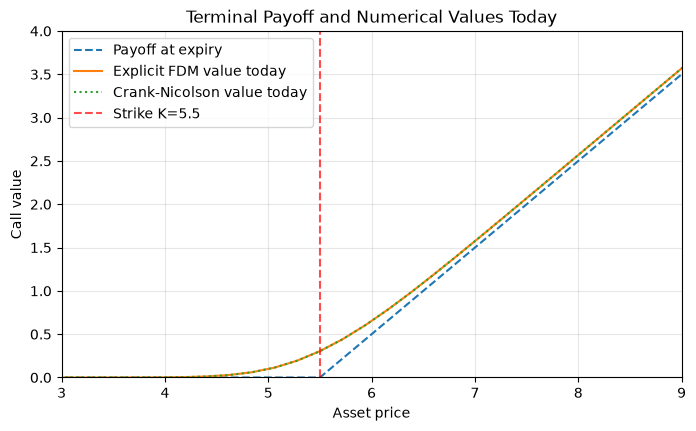

In [18]:
asset_grid = explicit.asset_grid
terminal_payoff = np.maximum(asset_grid - K, 0.0)

plt.figure(figsize=(8, 4.5))
plt.plot(asset_grid, terminal_payoff, "--", label="Payoff at expiry")
plt.plot(asset_grid, explicit.value_grid, label="Explicit FDM value today")
plt.plot(asset_grid, crank_nicolson.value_grid, ":", label="Crank-Nicolson value today")
plt.axvline(K, color="red", linestyle="--", alpha=0.7, label=f"Strike K={K}")
plt.xlim(3, 9)
plt.ylim(0, 4)
plt.xlabel("Asset price")
plt.ylabel("Call value")
plt.title("Terminal Payoff and Numerical Values Today")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Paper-inspired convection sensitivity

The paper proposes weakening or enhancing the convection term. Since its full tuning function is not reproducible from the text, the experiment below varies a transparent fixed multiplier. `theta=1` is the standard Black-Scholes convection term; values below or above one weaken or strengthen it.

In [19]:
sensitivity_rows = []
for theta in [0.75, 0.90, 1.00, 1.10, 1.25]:
    result = scaled_convection_fdm_price(
        S0, K, T, r, sigma, "call", M, N, theta=theta
    )
    sensitivity_rows.append({
        "theta": theta,
        "price": result.price,
        "absolute_error": abs(result.price - exact),
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.round(6)

,theta,price,absolute_error
0,0.75,0.095054,0.003972
1,0.90,0.097585,0.001441
2,1.00,0.099300,0.000274
3,1.10,0.101037,0.002012
4,1.25,0.103686,0.004661


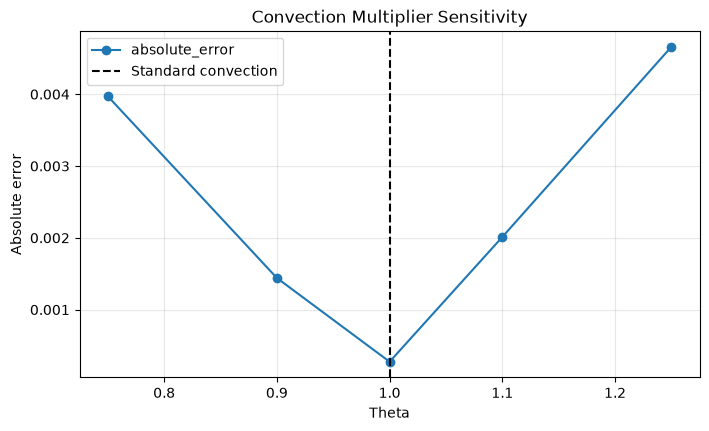

In [20]:
ax = sensitivity.plot(
    x="theta", y="absolute_error", marker="o", legend=False, figsize=(8, 4.5)
)
ax.axvline(1.0, color="black", linestyle="--", label="Standard convection")
ax.set(title="Convection Multiplier Sensitivity", xlabel="Theta", ylabel="Absolute error")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Numerical conclusion

For the baseline case, both independently implemented finite-difference methods closely match the analytical value. Monte Carlo is also close but retains sampling uncertainty. On this grid, changing the convection multiplier away from one does not improve the baseline error, so the paper's broad superiority claim is not established by this transparent sensitivity experiment.